# Cleaning up the learned graphs
The goal of this notebook is to ensure all the learned graphs are represented in the form of Directed Acyclic Graphs (DAGs). This means removing cycles or turning PDAG and PAGs into DAGs.

In [ ]:
# Data manipulation and plotting
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import re
import json 
import glob

# Local imports
from simplify_graph import *

from itertools import combinations

## Clininian's Consensus DAG
This graph will be our baseline since there isn't a ground truth for neuromorbidity in the PICU.

In [2]:
adjacency_matrix = pd.read_csv('../Datasets/bk_adjacency.csv', index_col=0)

In [20]:
adjacency_matrix = pd.read_csv('../Datasets/bk_adjacency.csv', index_col=0)
consensus_dag = nx.DiGraph(adjacency_matrix)

# Remove isolated nodes
consensus_dag.remove_nodes_from(list(nx.isolates(consensus_dag)))
print(list(consensus_dag.predecessors('Outcome')))
# Contract nodes in the outcome_cols list into a single 'Outcome' node
outcome_cols = ['BH', 'EEG',  'CT',	'MRI', 'Meds', 'BHMeds', 'Haloperidol', 'Olanzapine', 'Dexmedetomidine']
for col in outcome_cols:
    if col in consensus_dag:
        consensus_dag = nx.contracted_nodes(consensus_dag, 'Outcome', col, self_loops=False)
consensus_dag.remove_edges_from(list(consensus_dag.out_edges('Outcome')))
print(f"Number of nodes: {consensus_dag.number_of_nodes()} | Number of edges: {consensus_dag.number_of_edges()}| Predecessors of Outcome: {len(list(consensus_dag.predecessors('Outcome')))} | Successors of Outcome: {len(list(consensus_dag.successors('Outcome')))}")           


# Simplified version for visualization
consensus_dag_simplified = nx.DiGraph(simplify_graph(adjacency_matrix = adjacency_matrix))
consensus_dag_simplified.remove_nodes_from(list(nx.isolates(consensus_dag_simplified)))
# Contract nodes in the outcome_cols list into a single 'Outcome' node
for col in outcome_cols:
    if col in consensus_dag_simplified:
        consensus_dag_simplified = nx.contracted_nodes(consensus_dag_simplified, 'Outcome', col, self_loops=False)
consensus_dag_simplified.remove_edges_from(list(consensus_dag_simplified.out_edges('Outcome')))
# consensus_dag_simplified.add_edges_from([('Base Deficit', 'Outcome')])
print(list(consensus_dag_simplified.predecessors('Outcome')))



print(f"Number of nodes: {consensus_dag_simplified.number_of_nodes()} | Number of edges: {consensus_dag_simplified.number_of_edges()}| Predecessors of Outcome: {len(list(consensus_dag_simplified.predecessors('Outcome')))} | Successors of Outcome: {len(list(consensus_dag_simplified.successors('Outcome')))}")

['BH', 'EEG', 'CT', 'MRI', 'Meds', 'BHMeds']
Number of nodes: 204 | Number of edges: 372| Predecessors of Outcome: 203 | Successors of Outcome: 0
['Cisatracurium', 'DBP', 'ECMO Type', 'Fentanyl', 'Hydromorphone', 'Lactate', 'Lorazepam', 'Midazolam', 'Morphine', 'Peds Coma Score', 'Pulse', 'Pupillary Reaction', 'Sodium', 'Ventilated', 'pH']
Number of nodes: 16 | Number of edges: 16| Predecessors of Outcome: 15 | Successors of Outcome: 0


## GOLEM
Our first step is to concatenate the results of all the bootstrapped runs of GOLEM and find a sensible threshold.

In [4]:
# Import all adjacency matrices from CRC folder
adjacency_matrixes = glob.glob('/Users/eddie/Library/Containers/io.mountainduck/Data/Library/Application Support/Mountain Duck/Volumes.noindex/Pitt CRC.localized/ix1/projects/causal_search_brain_ai/GradientBased/golem/global/bk_matrix/*_golem_matrix_bk.csv')
print(f"Number of adjacency matrices: {len(adjacency_matrixes)}")
print(pd.read_csv(adjacency_matrixes[0], header=None).shape) # Print first file path to verify

search_data= pd.read_csv('../Datasets/gradient_set.csv')
col_labels = search_data.columns.to_list()
print(f"Search data shape: {search_data.shape}")




adjacency_matrixes = np.array([pd.read_csv(matrix, header=None).to_numpy() for matrix in adjacency_matrixes])

        
# Pool Biomarkers and Adjacency Matrices
print(f"Bootstraps = {adjacency_matrixes.shape[0]} | Features = {adjacency_matrixes.shape[0]}, {adjacency_matrixes.shape[1]}")
pool = pd.DataFrame(np.mean(adjacency_matrixes, axis=0), index=col_labels, columns=col_labels)
print(pool.shape)

print(f"Threshold = 0 | Edges = {(pool > 0).sum().sum()}")
print(f"Threshold = 0.02 | Edges = {(pool >= 0.02).sum().sum()}")
print(f"Threshold = 0.05 | Edges = {(pool >= 0.05).sum().sum()}")
print(f"Threshold = 0.07 | Edges = {(pool >= 0.07).sum().sum()}")
print(f"Threshold = 0.09 | Edges = {(pool >= 0.09).sum().sum()}")
print(f"Threshold = 0.1 | Edges = {(pool >= 0.1).sum().sum()}")
print(f"Threshold = 0.2 | Edges = {(pool >= 0.2).sum().sum()}")
print(f"Threshold = 0.3 | Edges = {(pool >= 0.3).sum().sum()}")
print(f"Threshold = 0.5 | Edges = {(pool >= 0.5).sum().sum()}")
print(f"Threshold = 0.7 | Edges = {(pool >= 0.7).sum().sum()}")
print(f"Threshold = 0.9 | Edges = {(pool >= 0.9).sum().sum()}")

Number of adjacency matrices: 50
(651, 651)
Search data shape: (13054, 651)
Bootstraps = 50 | Features = 50, 651
(651, 651)
Threshold = 0 | Edges = 33471
Threshold = 0.02 | Edges = 33471
Threshold = 0.05 | Edges = 1887
Threshold = 0.07 | Edges = 766
Threshold = 0.09 | Edges = 445
Threshold = 0.1 | Edges = 445
Threshold = 0.2 | Edges = 109
Threshold = 0.3 | Edges = 50
Threshold = 0.5 | Edges = 20
Threshold = 0.7 | Edges = 8
Threshold = 0.9 | Edges = 3


In [19]:
threshold = 0.1 # We will only include edges with an average weight >= threshold

golem_dag = nx.DiGraph(pool >= threshold, with_labels=True)

# Remove isolated nodes from both DAGs
golem_dag.remove_nodes_from(list(nx.isolates(golem_dag)))

print(f"Number of nodes: {golem_dag.number_of_nodes()} | Number of edges: {golem_dag.number_of_edges()}| Predecessors of Outcome: {len(list(golem_dag.predecessors('Outcome')))} | Successors of Outcome: {len(list(golem_dag.successors('Outcome')))}")

# Identify successors of Outcome and flip edges
out_edges_outcome = list(golem_dag.out_edges('Outcome'))
golem_dag.remove_edges_from(out_edges_outcome) # Remove outgoing edges from Outcome
golem_dag.add_edges_from([(edge[1], edge[0]) for edge in out_edges_outcome]) # Reverse edges from Outcome to its children


# Contract nodes in the outcome_cols list into a single 'Outcome' node
outcome_cols = ['BH', 'EEG',  'CT',	'MRI', 'Meds', 'BHMeds', 'Haloperidol', 'Olanzapine', 'Dexmedetomidine']
for col in outcome_cols:
    if col in golem_dag:
        golem_dag = nx.contracted_nodes(golem_dag, 'Outcome', col, self_loops=False)


golem_dag.remove_edges_from(list(golem_dag.out_edges('Outcome'))) # Remove outgoing edges from Outcome


# Keep nodes only in the markov blanket
golem_dag = nx.DiGraph(golem_dag.subgraph(list(golem_dag.predecessors('Outcome')) + ['Outcome']))

count = 0
while nx.is_directed_acyclic_graph(golem_dag) == False:
    cycle = nx.find_cycle(golem_dag)
    # print(cycle)
    golem_dag.remove_edge(cycle[-1][0], cycle[-1][1])
    count += 1
print(f"Number of edges removed to achieve acyclicity: {count}")
print(f"Number of nodes: {golem_dag.number_of_nodes()} | Number of edges: {golem_dag.number_of_edges()}| Predecessors of Outcome: {len(list(golem_dag.predecessors('Outcome')))} | Successors of Outcome: {len(list(golem_dag.successors('Outcome')))}")



# Simplified version for visualization
golem_dag_simplified = nx.DiGraph(simplify_graph(adjacency_matrix = pool >= threshold))
print(f"Number of nodes: {golem_dag_simplified.number_of_nodes()} | Number of edges: {golem_dag_simplified.number_of_edges()}| Predecessors of Outcome: {len(list(golem_dag_simplified.predecessors('Outcome')))} | Successors of Outcome: {len(list(golem_dag_simplified.successors('Outcome')))}")

# Identify successors of Outcome and flip edges
out_edges_outcome = list(golem_dag_simplified.out_edges('Outcome'))
golem_dag_simplified.remove_edges_from(out_edges_outcome) # Remove outgoing edges from Outcome
golem_dag_simplified.add_edges_from([(edge[1], edge[0]) for edge in out_edges_outcome]) # Reverse edges from Outcome to its children

# Contract nodes in the outcome_cols list into a single 'Outcome' node
outcome_cols = ['BH', 'EEG',  'CT',	'MRI', 'Meds', 'Haloperidol', 'BHMeds', 'Olanzapine', 'Dexmedetomidine']
for col in outcome_cols:
    if col in golem_dag_simplified:
        golem_dag_simplified = nx.contracted_nodes(golem_dag_simplified, 'Outcome', col, self_loops=False)
golem_dag_simplified.remove_edges_from(list(golem_dag_simplified.out_edges('Outcome')))
golem_dag_simplified.remove_nodes_from(list(nx.isolates(golem_dag_simplified)))
golem_dag_simplified.remove_edges_from(nx.selfloop_edges(golem_dag_simplified))
golem_dag_simplified = nx.DiGraph(golem_dag_simplified.subgraph(list(golem_dag_simplified.predecessors('Outcome')) + ['Outcome']))

count = 0
while nx.is_directed_acyclic_graph(golem_dag_simplified) == False:
    cycle = nx.find_cycle(golem_dag_simplified)
    # print(cycle)
    golem_dag_simplified.remove_edge(cycle[-1][0], cycle[-1][1])
    count += 1
print(f"Number of edges removed to achieve acyclicity: {count}")

print(f"Number of nodes: {golem_dag_simplified.number_of_nodes()} | Number of edges: {golem_dag_simplified.number_of_edges()}| Predecessors of Outcome: {len(list(golem_dag_simplified.predecessors('Outcome')))} | Successors of Outcome: {len(list(golem_dag_simplified.successors('Outcome')))}")

Number of nodes: 284 | Number of edges: 445| Predecessors of Outcome: 3 | Successors of Outcome: 3
Number of edges removed to achieve acyclicity: 3
Number of nodes: 17 | Number of edges: 24| Predecessors of Outcome: 16 | Successors of Outcome: 0
Number of nodes: 54 | Number of edges: 261| Predecessors of Outcome: 3 | Successors of Outcome: 3
Number of edges removed to achieve acyclicity: 4
Number of nodes: 12 | Number of edges: 22| Predecessors of Outcome: 11 | Successors of Outcome: 0


## PC-MB

In [17]:
def simplify_graph(adjacency_matrix: pd.DataFrame = None, graph: nx.DiGraph = None) -> pd.DataFrame:
    """
    Simplify a directed graph by pooling features with the same biomarker prefix.

    Parameters:
    graph (nx.DiGraph): The input directed graph to be simplified.
    adjacency_matrix (pd.DataFrame): The adjacency matrix of the graph.
    Returns:
    pd.DataFrame: A simplified adjacency matrix with pooled features.
    """
    # If a graph is provided, extract its adjacency matrix
    if graph is not None:
        adj = nx.to_pandas_adjacency(graph, dtype=int)
    else:
        adj = adjacency_matrix.copy()
    # Ensure the adjacency matrix is square
    assert adj.shape[0] == adj.shape[1], "Adjacency matrix must be square."
    # Ensure the adjacency matrix is labeled correctly
    assert all(adj.index == adj.columns), "Adjacency matrix must have matching row and column labels."
    
    # Pool features
    adj.columns = adj.columns.str.replace('_.+', '', regex=True)
    adj.index = adj.index.str.replace('_.+', '', regex=True)
    
    # Groupby col name
    adj = adj.groupby(adj.index).mean()
    adj = adj.T.groupby(adj.columns).mean().T

    # Convert to binary adjacency matrix
    return (adj > 0).astype(int)

In [18]:
# Path to PC-MB graph in the CRC folder
path = '/Users/eddie/Library/Containers/io.mountainduck/Data/Library/Application Support/Mountain Duck/Volumes.noindex/Pitt CRC.localized/ix1/projects/causal_search_brain_ai/tetrad/pc-mb/pcmb_1754940696523_graph.json'

import json
with open(path, 'r') as f:
    pcmb_graph = json.load(f)

pcmb_dag = nx.DiGraph()

for node in pcmb_graph['nodes']:
    pcmb_dag.add_node(node['name'])

for edgeset in pcmb_graph['edgesSet']:
    pcmb_dag.add_edge(edgeset['node1']['name'], edgeset['node2']['name'])

print(f"Number of nodes: {pcmb_dag.number_of_nodes()} | Number of edges: {pcmb_dag.number_of_edges()}| Predecessors of Outcome: {len(list(pcmb_dag.predecessors('Outcome')))} | Successors of Outcome: {len(list(pcmb_dag.successors('Outcome')))}")
pcmb_dag.remove_nodes_from(list(nx.isolates(pcmb_dag)))

# We remove edges that are known to be incorrect based on domain knowledge and to prevent cycles
pcmb_dag.remove_edge('CT', 'Dexmedetomidine')
pcmb_dag.remove_edge('EEG', 'Base excess__SB_BinaryStats_diff_longstretch0')



# Contract nodes in the outcome_cols list into a single 'Outcome' node
outcome_cols = ['BH', 'EEG',  'CT',	'MRI', 'Meds', 'Haloperidol', 'Olanzapine', 'Dexmedetomidine']
for col in outcome_cols:
    if col in pcmb_dag:
        pcmb_dag = nx.contracted_nodes(pcmb_dag, 'Outcome', col, self_loops=False)
pcmb_dag.remove_edges_from(list(pcmb_dag.out_edges('Outcome')))
print(f"Number of nodes: {pcmb_dag.number_of_nodes()} | Number of edges: {pcmb_dag.number_of_edges()}| Predecessors of Outcome: {len(list(pcmb_dag.predecessors('Outcome')))} | Successors of Outcome: {len(list(pcmb_dag.successors('Outcome')))}")
print(nx.is_directed_acyclic_graph(pcmb_dag))
print(list(pcmb_dag.edges('Base excess__SB_BinaryStats_diff_longstretch0')))

# Simplified view for plotting
pcmb_dag_simplified = nx.DiGraph(simplify_graph(adjacency_matrix=nx.to_pandas_adjacency(pcmb_dag)))
print(list(pcmb_dag_simplified.predecessors('Outcome')))
pcmb_dag_simplified.remove_nodes_from(list(nx.isolates(pcmb_dag_simplified)))
# Contract nodes in the outcome_cols list into a single 'Outcome' node
outcome_cols = ['BH', 'EEG',  'CT',	'MRI', 'Meds', 'Haloperidol', 'Olanzapine', 'Dexmedetomidine']
for col in outcome_cols:
    if col in pcmb_dag_simplified:
        pcmb_dag_simplified = nx.contracted_nodes(pcmb_dag_simplified, 'Outcome', col, self_loops=False)
pcmb_dag_simplified.remove_edges_from(list(pcmb_dag_simplified.out_edges('Outcome')))
# Remove self loops
pcmb_dag_simplified.remove_edges_from(nx.selfloop_edges(pcmb_dag_simplified))
# Remove successors of outcome
pcmb_dag_simplified = nx.DiGraph(pcmb_dag_simplified.subgraph(list(pcmb_dag_simplified.predecessors('Outcome')) + ['Outcome']))

count = 0
while nx.is_directed_acyclic_graph(pcmb_dag_simplified) == False:
    cycle = nx.find_cycle(pcmb_dag_simplified)
    print(cycle)
    pcmb_dag_simplified.remove_edge(cycle[-1][0], cycle[-1][1])
    count += 1
print(f"Number of edges removed to achieve acyclicity: {count}")


print(f"Number of nodes: {pcmb_dag_simplified.number_of_nodes()} | Number of edges: {pcmb_dag_simplified.number_of_edges()}| Predecessors of Outcome: {len(list(pcmb_dag_simplified.predecessors('Outcome')))} | Successors of Outcome: {len(list(pcmb_dag_simplified.successors('Outcome')))}")

Number of nodes: 41 | Number of edges: 146| Predecessors of Outcome: 5 | Successors of Outcome: 0
Number of nodes: 32 | Number of edges: 78| Predecessors of Outcome: 30 | Successors of Outcome: 0
True
[('Base excess__SB_BinaryStats_diff_longstretch0', 'Dobutamine__SB_TransitionMatrix_3ac_sumdiagcov')]
['Cisatracurium', 'DBP', 'Dobutamine', 'Fentanyl', 'Glucose', 'Hydromorphone', 'Lactate', 'Lorazepam', 'Midazolam', 'Morphine', 'PTT', 'Peds Coma Score', 'Pulse', 'Pupillary Reaction', 'Sodium', 'Ventilated', 'pH']
[('Morphine', 'Midazolam'), ('Midazolam', 'Morphine')]
[('DBP', 'Sodium'), ('Sodium', 'Fentanyl'), ('Fentanyl', 'DBP')]
Number of edges removed to achieve acyclicity: 2
Number of nodes: 18 | Number of edges: 50| Predecessors of Outcome: 17 | Successors of Outcome: 0


## Enhanced DAGS

In [8]:
simplified = { 
    'Simplified Clinician Consensus': consensus_dag_simplified, 
    'Simplified Golem': golem_dag_simplified, 
    'Simplified PCMB': pcmb_dag_simplified,
}

full = {
    'Clinician Consensus': consensus_dag, 
    'Golem': golem_dag, 
    'PCMB': pcmb_dag
    }


### DAG Unions

In [ ]:
simplified_unions = {}

for dag1, dag2 in combinations(simplified.keys(), 2):
    combined_dag = nx.compose(simplified[dag1].copy(), simplified[dag2].copy())
    print(f"Combination of {dag1} and {dag2}:")
    print(f"Number of nodes: {combined_dag.number_of_nodes()} | Number of edges: {combined_dag.number_of_edges()}| Predecessors of Outcome: {len(list(combined_dag.predecessors('Outcome')))} | Successors of Outcome: {len(list(combined_dag.successors('Outcome')))}")
    count = 0
    while nx.is_directed_acyclic_graph(combined_dag) == False:
        cycle = nx.find_cycle(combined_dag)
        # print(cycle)
        combined_dag.remove_edge(cycle[-1][0], cycle[-1][1])
        count += 1
    print(f"Number of edges removed to achieve acyclicity: {count}")
    print("")
    simplified_unions[f"{dag1} + {dag2}"] = combined_dag

unions = {}

for dag1, dag2 in combinations(full.keys(), 2):
    combined_dag = nx.compose(full[dag1].copy(), full[dag2].copy())
    print(f"Combination of {dag1} and {dag2}:")
    print(f"Number of nodes: {combined_dag.number_of_nodes()} | Number of edges: {combined_dag.number_of_edges()}| Predecessors of Outcome: {len(list(combined_dag.predecessors('Outcome')))} | Successors of Outcome: {len(list(combined_dag.successors('Outcome')))}")
    count = 0
    while nx.is_directed_acyclic_graph(combined_dag) == False:
        cycle = nx.find_cycle(combined_dag)
        # print(cycle)
        combined_dag.remove_edge(cycle[-1][0], cycle[-1][1])
        count += 1
    print(f"Number of edges removed to achieve acyclicity: {count}")
    print("")
    unions[f"{dag1} + {dag2}"] = combined_dag

Combination of Simplified Clinician Consensus and Simplified Golem:
Number of nodes: 23 | Number of edges: 34| Predecessors of Outcome: 22 | Successors of Outcome: 0
Number of edges removed to achieve acyclicity: 0

Combination of Simplified Clinician Consensus and Simplified PCMB:
Number of nodes: 19 | Number of edges: 52| Predecessors of Outcome: 18 | Successors of Outcome: 0
Number of edges removed to achieve acyclicity: 0

Combination of Simplified Golem and Simplified PCMB:
Number of nodes: 24 | Number of edges: 67| Predecessors of Outcome: 23 | Successors of Outcome: 0
Number of edges removed to achieve acyclicity: 3

Combination of Clinician Consensus and Golem:
Number of nodes: 213 | Number of edges: 387| Predecessors of Outcome: 212 | Successors of Outcome: 0
Number of edges removed to achieve acyclicity: 0

Combination of Clinician Consensus and PCMB:
Number of nodes: 215 | Number of edges: 430| Predecessors of Outcome: 213 | Successors of Outcome: 0
Number of edges removed t

### DAG Intersections

In [ ]:
simplified_intersections = {}
for dag1, dag2 in combinations(simplified.keys(), 2):
    intersection_dag = nx.intersection(simplified[dag1].copy(), simplified[dag2].copy())
    print(f"Intersection of {dag1} and {dag2}:")
    print(f"Number of nodes: {intersection_dag.number_of_nodes()} | Number of edges: {intersection_dag.number_of_edges()}| Predecessors of Outcome: {len(list(intersection_dag.predecessors('Outcome')))} | Successors of Outcome: {len(list(intersection_dag.successors('Outcome')))}")
    count = 0
    while nx.is_directed_acyclic_graph(intersection_dag) == False:
        cycle = nx.find_cycle(intersection_dag)
        # print(cycle)
        intersection_dag.remove_edge(cycle[-1][0], cycle[-1][1])
        count += 1
    print(f"Number of edges removed to achieve acyclicity: {count}")
    print("")
    simplified_intersections[f"{dag1} x {dag2}"] = intersection_dag

intersections = {}
for dag1, dag2 in combinations(full.keys(), 2):
    intersection_dag = nx.intersection(full[dag1].copy(), full[dag2].copy())
    print(f"Intersection of {dag1} and {dag2}:")
    print(f"Number of nodes: {intersection_dag.number_of_nodes()} | Number of edges: {intersection_dag.number_of_edges()}| Predecessors of Outcome: {len(list(intersection_dag.predecessors('Outcome')))} | Successors of Outcome: {len(list(intersection_dag.successors('Outcome')))}")
    count = 0
    while nx.is_directed_acyclic_graph(intersection_dag) == False:
        cycle = nx.find_cycle(intersection_dag)
        # print(cycle)
        intersection_dag.remove_edge(cycle[-1][0], cycle[-1][1])
        count += 1
    print(f"Number of edges removed to achieve acyclicity: {count}")
    print("")
    intersections[f"{dag1} x {dag2}"] = intersection_dag

Intersection of Simplified Clinician Consensus and Simplified Golem:
Number of nodes: 5 | Number of edges: 4| Predecessors of Outcome: 4 | Successors of Outcome: 0
Number of edges removed to achieve acyclicity: 0

Intersection of Simplified Clinician Consensus and Simplified PCMB:
Number of nodes: 15 | Number of edges: 14| Predecessors of Outcome: 14 | Successors of Outcome: 0
Number of edges removed to achieve acyclicity: 0

Intersection of Simplified Golem and Simplified PCMB:
Number of nodes: 6 | Number of edges: 5| Predecessors of Outcome: 5 | Successors of Outcome: 0
Number of edges removed to achieve acyclicity: 0

Intersection of Clinician Consensus and Golem:
Number of nodes: 8 | Number of edges: 7| Predecessors of Outcome: 7 | Successors of Outcome: 0
Number of edges removed to achieve acyclicity: 0

Intersection of Clinician Consensus and PCMB:
Number of nodes: 21 | Number of edges: 20| Predecessors of Outcome: 20 | Successors of Outcome: 0
Number of edges removed to achieve 

## Drawing DAGs

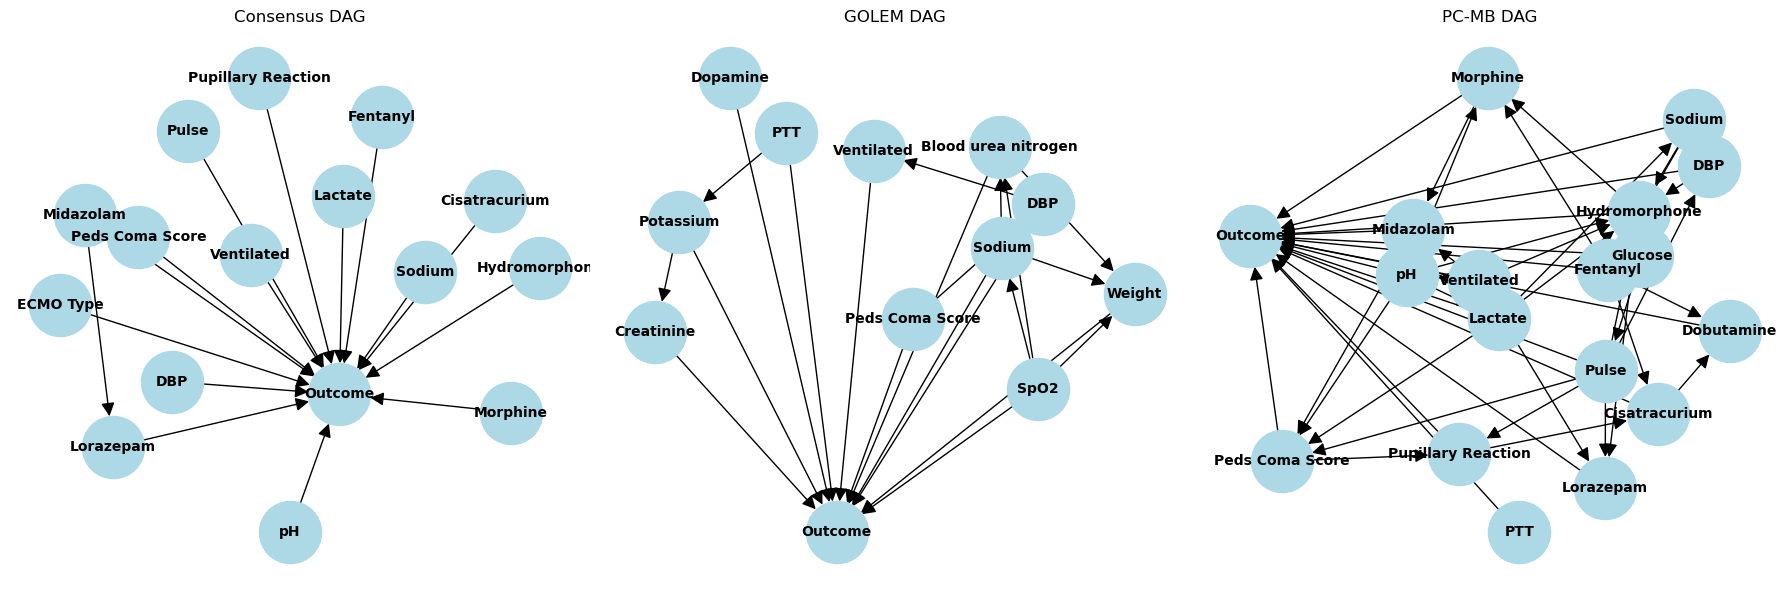

In [46]:
# A plot of all the simplified dags in one figure for comparison
dags = [consensus_dag_simplified, golem_dag_simplified, pcmb_dag_simplified]
plt.figure(figsize=(18, 6))
for i, dag in enumerate(dags):
    plt.subplot(1, 3, i+1)
    # pos = nx.nx_agraph.graphviz_layout(dag)
    nx.draw(dag, with_labels=True, arrows=True, node_size=2000, node_color='lightblue', font_size=10, font_weight='bold', arrowsize=20)
    plt.title(['Consensus DAG', 'GOLEM DAG', 'PC-MB DAG'][i])
plt.tight_layout()
plt.show()


In [9]:
print(f"Number of nodes: {pcmb_dag.number_of_nodes()} | Number of edges: {pcmb_dag.number_of_edges()}| Predecessors of Outcome: {len(list(pcmb_dag.predecessors('Outcome')))} | Successors of Outcome: {len(list(pcmb_dag.successors('Outcome')))}")
pcmb_dag = pcmb_dag.subgraph(list(pcmb_dag.predecessors('Outcome')) + ['Outcome'])
print(f"Number of nodes: {pcmb_dag.number_of_nodes()} | Number of edges: {pcmb_dag.number_of_edges()}| Predecessors of Outcome: {len(list(pcmb_dag.predecessors('Outcome')))} | Successors of Outcome: {len(list(pcmb_dag.successors('Outcome')))}")

print(f"Number of nodes: {golem_dag.number_of_nodes()} | Number of edges: {golem_dag.number_of_edges()}| Predecessors of Outcome: {len(list(golem_dag.predecessors('Outcome')))} | Successors of Outcome: {len(list(golem_dag.successors('Outcome')))}")
golem_dag = golem_dag.subgraph(list(golem_dag.predecessors('Outcome')) + ['Outcome'])
print(f"Number of nodes: {golem_dag.number_of_nodes()} | Number of edges: {golem_dag.number_of_edges()}| Predecessors of Outcome: {len(list(golem_dag.predecessors('Outcome')))} | Successors of Outcome: {len(list(golem_dag.successors('Outcome')))}")

Number of nodes: 32 | Number of edges: 78| Predecessors of Outcome: 30 | Successors of Outcome: 0
Number of nodes: 31 | Number of edges: 76| Predecessors of Outcome: 30 | Successors of Outcome: 0
Number of nodes: 17 | Number of edges: 24| Predecessors of Outcome: 16 | Successors of Outcome: 0
Number of nodes: 17 | Number of edges: 24| Predecessors of Outcome: 16 | Successors of Outcome: 0


In [ ]:
# A plot of all the simplified dags in one figure for comparison
import matplotlib

dags = [consensus_dag, golem_dag, pcmb_dag]
names = ['Clinician Consensus', 'GOLEM (MB)', 'PC-MB']
for i, dag in enumerate(dags):
    plt.figure(figsize=(18, 18))
    plt.title(f'{names[i]} DAG')
    plt.rcParams['font.size'] = 18
    print(f"Saving {names[i]} DAG with {dag.number_of_nodes()} nodes and {dag.number_of_edges()} edges.")
    pos = nx.spring_layout(dag, k=0.5, iterations=100)
    nx.draw(dag, pos, with_labels=True, arrows=True, node_size=2000, node_color='lightblue', font_size=10, font_weight='bold', arrowsize=20)
    plt.savefig(f'../DAGs/{names[i]}.pdf', bbox_inches='tight', dpi=300)
    plt.show()


Saving Clinician Consensus DAG with 204 nodes and 372 edges.
Saving GOLEM (MB) DAG with 17 nodes and 24 edges.
Saving PC-MB DAG with 31 nodes and 76 edges.


## Saving the DAGs as Adjacency Matrixes

In [47]:
# Join dag dictionaries
dags = {**simplified, **full, **simplified_unions, **unions, **simplified_intersections, **intersections}

for name, dag in dags.items():
    print(f"Saving {name} with {dag.number_of_nodes()} nodes and {dag.number_of_edges()} edges")
    # Pandas adjacency matrix
    pd.DataFrame(nx.to_pandas_adjacency(dag)).to_csv(f'../DAGs/{name}_adjacency.csv')
    #nx.write_edgelist(dag, path = f'{name}_edgelist.gz')
    #nx.write_adjlist(dag, path = f'{name}_adjlist.gz')

Saving Simplified Clinician Consensus with 16 nodes and 16 edges
Saving Simplified Golem with 12 nodes and 22 edges
Saving Simplified PCMB with 18 nodes and 50 edges
Saving Clinician Consensus with 204 nodes and 372 edges
Saving Golem with 17 nodes and 22 edges
Saving PCMB with 32 nodes and 78 edges
Saving Simplified Clinician Consensus + Simplified Golem with 23 nodes and 34 edges
Saving Simplified Clinician Consensus + Simplified PCMB with 19 nodes and 52 edges
Saving Simplified Golem + Simplified PCMB with 24 nodes and 64 edges
Saving Clinician Consensus + Golem with 213 nodes and 387 edges
Saving Clinician Consensus + PCMB with 215 nodes and 430 edges
Saving Golem + PCMB with 48 nodes and 100 edges
Saving Simplified Clinician Consensus x Simplified Golem with 5 nodes and 4 edges
Saving Simplified Clinician Consensus x Simplified PCMB with 15 nodes and 14 edges
Saving Simplified Golem x Simplified PCMB with 6 nodes and 5 edges
Saving Clinician Consensus x Golem with 8 nodes and 7 ed

In [49]:
for dag_name, dag in dags.items():
    print(f"{dag_name} | {len(dag.nodes())-1}")

Simplified Clinician Consensus | 15
Simplified Golem | 11
Simplified PCMB | 17
Clinician Consensus | 203
Golem | 16
PCMB | 31
Simplified Clinician Consensus + Simplified Golem | 22
Simplified Clinician Consensus + Simplified PCMB | 18
Simplified Golem + Simplified PCMB | 23
Clinician Consensus + Golem | 212
Clinician Consensus + PCMB | 214
Golem + PCMB | 47
Simplified Clinician Consensus x Simplified Golem | 4
Simplified Clinician Consensus x Simplified PCMB | 14
Simplified Golem x Simplified PCMB | 5
Clinician Consensus x Golem | 7
Clinician Consensus x PCMB | 20
Golem x PCMB | 0


# Export features as table

In [6]:
#Get all adjacency files
adjacency_files = glob.glob("../DAGs/*_adjacency.csv")

dags = {}
for file in adjacency_files:
    dag_name = re.search(r'../DAGs/(.*)_adjacency.csv', file).group(1)
    dag_name = dag_name.replace('x', '$\\cap$')
    dag_name = dag_name.replace(' + ', ' $\\cup$ ')
    dags[dag_name] = nx.DiGraph(pd.read_csv(file, index_col=0))

dags.pop('Golem $\\cap$ PCMB')  # Remove problematic DAG (has 0 nodes associated with Outcome)
list(dags.keys())
# Only Interested in GOLEM and PCMB
golem_dag = dags['Golem']
pcmb_dag = dags['PCMB']

In [19]:
golem_nodes = pd.Series(list(golem_dag.nodes()), name='Golem Nodes')
pcmb_nodes = pd.Series(list(pcmb_dag.nodes()), name='PCMB Nodes')

golem_nodes = golem_nodes.str.split('__', expand=True).rename(columns={0: 'Biomarker', 1: 'Feature'})
pcmb_nodes = pcmb_nodes.str.split('__', expand=True).rename(columns={0: 'Biomarker', 1: 'Feature'})

golem_nodes.Feature.value_counts().to_csv("../DAGs/golem_features.csv")
pcmb_nodes.Feature.value_counts().to_csv("../DAGs/pcmb_features.csv")

# Venn Diagram of Biomarkers

In [152]:
set3

{'Cisatracurium',
 'DBP',
 'ECMO Type',
 'Fentanyl',
 'Hydromorphone',
 'Lactate',
 'Lorazepam',
 'Midazolam',
 'Morphine',
 'Outcome',
 'Peds Coma Score',
 'Pulse',
 'Pupillary Reaction',
 'Sodium',
 'Ventilated',
 'pH'}

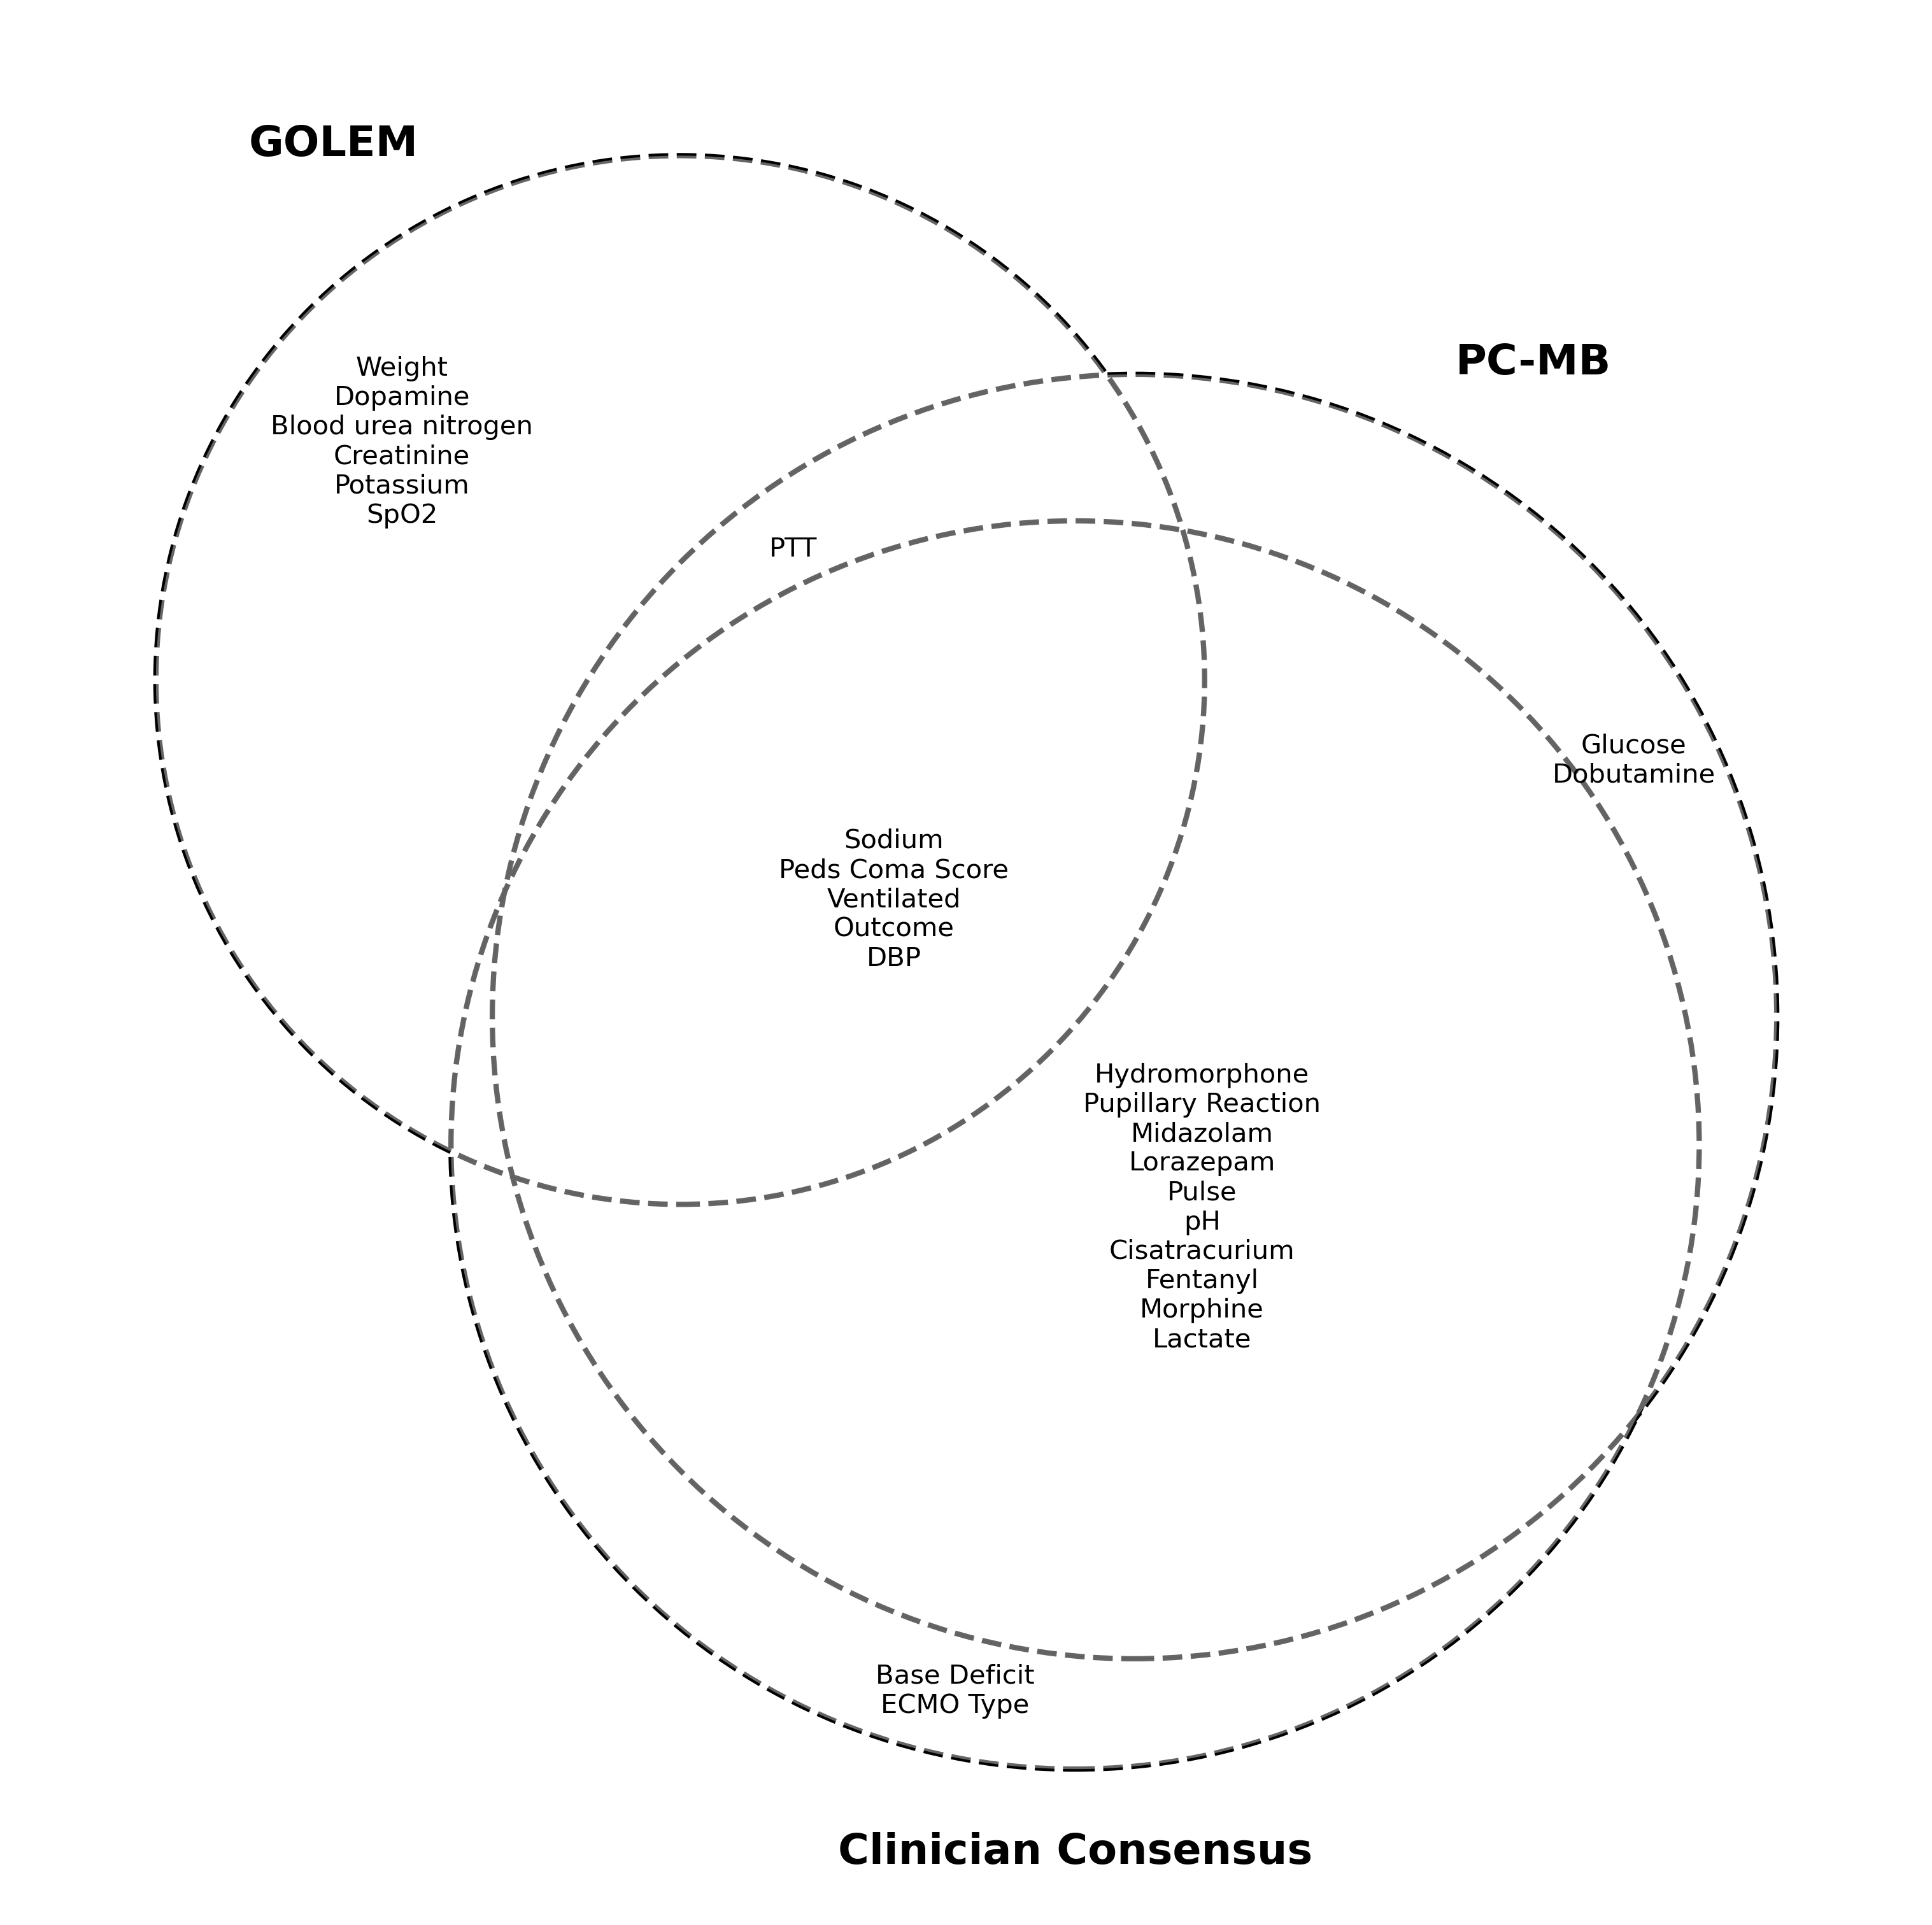

In [23]:
from matplotlib_venn import venn3, venn3_circles, venn3_unweighted
from matplotlib_venn.layout.venn3 import cost_based
import matplotlib as mpl


set1 = set(golem_dag_simplified.nodes())
set2 = set(pcmb_dag_simplified.nodes())
consensus_dag_simplified.add_node('Base Deficit')
set3 = set(consensus_dag_simplified.nodes())

# # Counts
# plt.figure(dpi=300, constrained_layout=True)
# venn3([set1, set2, set3], ('GOLEM', 'PC-MB', 'Clinician Consensus'))
# plt.title("Venn Diagram of Nodes in Simplified DAGs")
# plt.show()

# Show biomarer names in each section instead of counts
plt.figure(figsize=(10,10), dpi=300, constrained_layout=True)
mpl.rcParams['pdf.fonttype'] = 42  # Ensure fonts are saved as Type 3 (editable) in PDF


c = venn3_circles([set1, set2, set3], linestyle='dashed', layout_algorithm=cost_based.LayoutAlgorithm())
v = venn3([set1, set2, set3], ('GOLEM', 'PC-MB', 'Clinician Consensus'), layout_algorithm=cost_based.LayoutAlgorithm(), set_colors=('white', 'white', 'white'))
v.get_label_by_id('100').set_text('\n'.join(set1 - set2 - set3))
v.get_label_by_id('010').set_text('\n'.join(set2 - set1 - set3))
v.get_label_by_id('001').set_text('\n'.join(set3 - set1 - set2))
v.get_label_by_id('110').set_text('\n'.join(set1 & set2 - set3))
v.get_label_by_id('101').set_text('\n'.join(set1 & set3 - set2))
v.get_label_by_id('011').set_text('\n'.join(set2 & set3 - set1))
v.get_label_by_id('111').set_text('\n'.join(set1 & set2 & set3))
v.set_labels[0].set_fontsize(16)
v.set_labels[1].set_fontsize(16)
v.set_labels[2].set_fontsize(16)    
v.set_labels[0].set_fontweight('bold')
v.set_labels[1].set_fontweight('bold')
v.set_labels[2].set_fontweight('bold')
plt.savefig("../DAGs/venn_diagram_nodes.pdf", backend='pgf', bbox_inches='tight', dpi=300)